In [1]:
# import pandas as pd
# import numpy as np
# import os
# import glob
# import re
# from tqdm import tqdm



In [2]:

# from pathlib import Path

# # Get current working directory as a Path object
# current_dir = Path.cwd()

# # Get parent directory
# root = current_dir.parent

# print(f"Root directory set to: {root}")

# FOLDER = root / "outputs" / "csv"/"wifi-random"
# OUTPUT = root / "outputs" / "combine_analysis" / "final_merged_training_dataset.csv"

# FILE_REGEX = r"wifi-random-(.*?)-seed(\d+)-(.+?)\.csv"

In [3]:

# def extract_run_id(filename):
#     m = re.search(FILE_REGEX, filename)
#     if not m:
#         return None
#     return f"{m.group(1)}-seed{m.group(2)}"


# # ============================================================
# # Scan folder and group files by simulation
# # ============================================================
# def scan_runs(folder):
#     runs = {}
#     for f in glob.glob(os.path.join(folder, "*.csv")):
#         base = os.path.basename(f)
#         run_id = extract_run_id(base)
#         if run_id is None:
#             continue

#         runs.setdefault(run_id, {})
#         if "nodedensity" in base:
#             runs[run_id]["nd"] = f
#         elif "modulation" in base:
#             runs[run_id]["mod"] = f
#         elif "perf" in base:
#             runs[run_id]["perf"] = f
#     return runs


# # ============================================================
# # Build NodeDensity intervals
# # ============================================================
# def build_intervals(df_nd):
#     df = df_nd.copy()
#     df["t_start"] = df["Duration_s"].cumsum().shift(fill_value=0)
#     df["t_end"] = df["t_start"] + df["Duration_s"]
#     return df


# # ============================================================
# # Compute interval features from modulation rows
# # Includes RSSI, Noise, SNR_computed, PhyRate
# # PLUS automatic encoding of Modulation types + channel frequencies
# # ============================================================
# def compute_interval_mod_features(df_mod, t_start, t_end):
#     df = df_mod.copy()

#     df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
#     df = df.dropna(subset=["time_s"])
#     df["SNR_computed"] = df["signal_dBm"] - df["noise_dBm"]

#     mask = (df["time_s"] >= t_start) & (df["time_s"] <= t_end)
#     df_slice = df.loc[mask]

#     if df_slice.empty:
#         return {}

#     features = {
#         # Base PHY stats
#         "Mod_RSSI_mean": df_slice["signal_dBm"].mean(),
#         "Mod_RSSI_min": df_slice["signal_dBm"].min(),
#         "Mod_RSSI_max": df_slice["signal_dBm"].max(),

#         "Mod_Noise_mean": df_slice["noise_dBm"].mean(),

#         "Mod_SNR_mean": df_slice["SNR_computed"].mean(),

#         "Mod_PhyRate_mean": df_slice["PhyRate_Mbps"].mean(),
#         "Mod_PhyRate_max": df_slice["PhyRate_Mbps"].max(),

#         "IntervalSamples": len(df_slice)
#     }

#     # Add Modulation counts
#     modulation_counts = df_slice["Modulation"].value_counts().to_dict()
#     for mod_type, count in modulation_counts.items():
#         features[f"Modulation_{mod_type}_count"] = count

#     # Add channel counts
#     channel_counts = df_slice["channel_MHz"].value_counts().to_dict()
#     for ch, count in channel_counts.items():
#         features[f"Channel_{ch}_count"] = count

#     return features


# # ============================================================
# # Aggregate perf.csv
# # ============================================================
# def compute_perf_features(df_perf):
#     return {
#         "Perf_Throughput": df_perf["Throughput(Mbps)"].mean(),
#         "Perf_Latency": df_perf["Latency_avg(ms)"].mean(),
#         "Perf_Jitter": df_perf["Jitter_avg(ms)"].mean(),
#         "Perf_Loss": df_perf["PacketLoss(%)"].mean(),
#     }


# # ============================================================
# # MAIN BUILD FUNCTION
# # ============================================================
# def build_dataset(runs):
#     all_rows = []

#     for run_id, fdict in tqdm(runs.items(), desc="Building dataset"):

#         if "nd" not in fdict:
#             continue

#         df_nd = pd.read_csv(fdict["nd"])
#         df_nd = build_intervals(df_nd)

#         df_mod = pd.read_csv(fdict["mod"]) if "mod" in fdict else None

#         df_perf = pd.read_csv(fdict["perf"]) if "perf" in fdict else None
#         perf_stats = compute_perf_features(df_perf) if df_perf is not None else {}

#         for _, ndrow in df_nd.iterrows():
#             record = ndrow.to_dict()
#             record["RunID"] = run_id

#             if df_mod is not None:
#                 mod_stats = compute_interval_mod_features(
#                     df_mod,
#                     t_start=float(ndrow["t_start"]),
#                     t_end=float(ndrow["t_end"])
#                 )
#                 record.update(mod_stats)

#             record.update(perf_stats)

#             all_rows.append(record)

#     return pd.DataFrame(all_rows)


# # ============================================================
# # EXECUTE
# # ============================================================
# runs = scan_runs(FOLDER)
# df_final = build_dataset(runs)
# df_final.to_csv(OUTPUT, index=False)

# df_final


In [4]:
import os
import re
import glob
import pandas as pd

# ============================================================
# Helpers
# ============================================================

def extract_seed(filename):
    """Extract seed (integer) from NS-3 CSV file name."""
    m = re.search(r"seed(\d+)", filename)
    return int(m.group(1)) if m else None

def extract_run_datetime(filename):
    """Extract timestamp pattern from file name."""
    m = re.search(r"wifi-random-(.*)-seed", filename)
    return m.group(1) if m else "Unknown"

# ============================================================
# Loaders
# ============================================================

def load_perf_file(path):
    df = pd.read_csv(path)
    df["Perf_Filename"] = os.path.basename(path)
    df["RandSeed"] = extract_seed(path)
    df["RunDateTime"] = extract_run_datetime(path)
    
    # Force safe float columns
    float_cols = [
        "Throughput(Mbps)", "Latency_avg(ms)", "Jitter_avg(ms)",
        "PacketLoss(%)", "Duration_s"
    ]
    for c in float_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_nodedensity_file(path):
    df = pd.read_csv(path)
    df["ND_Filename"] = os.path.basename(path)
    df["RandSeed"] = extract_seed(path)
    df["RunDateTime"] = extract_run_datetime(path)
    
    # Parse timestamp columns safely
    df["StartDateTime"] = pd.to_datetime(df["StartDateTime"], errors="coerce")
    df["EndDateTime"]   = pd.to_datetime(df["EndDateTime"], errors="coerce")
    
    return df


# ============================================================
# Merging Logic
# ============================================================

def merge_perf_and_nodedensity(df_perf, df_nd):
    """
    NS-3 perf rows = per-flow
    NS-3 nodedensity rows = per-interval (No FlowID)

    We expand perf metrics to interval level by computing:
       avg throughput across flows in simulation
       avg latency, avg jitter
    """

    # performance averages across flows
    perf_avg = df_perf.groupby(["RandSeed", "RunDateTime"]).agg({
        "Throughput(Mbps)": "mean",
        "Latency_avg(ms)":  "mean",
        "Jitter_avg(ms)":   "mean",
        "PacketLoss(%)":    "mean"
    }).reset_index().rename(columns={
        "Throughput(Mbps)": "Perf_Avg_Throughput",
        "Latency_avg(ms)":  "Perf_Avg_Latency",
        "Jitter_avg(ms)":   "Perf_Avg_Jitter",
        "PacketLoss(%)":    "Perf_Avg_Loss"
    })

    # direct join (1 perf summary per simulation)
    df = df_nd.merge(perf_avg, on=["RandSeed","RunDateTime"], how="left")

    return df


# ============================================================
# Master Pipeline
# ============================================================

def build_training_dataset(root_dir, out_csv="final_training_dataset.csv"):
    """
    root_dir: folder containing files:
        *-perf.csv
        *-nodedensity.csv
    """

    perf_files = sorted(glob.glob(os.path.join(root_dir, "*-perf.csv")))
    nd_files   = sorted(glob.glob(os.path.join(root_dir, "*-nodedensity.csv")))

    print(f"Found {len(perf_files)} perf files")
    print(f"Found {len(nd_files)} nodedensity files")

    all_rows = []

    for pf in perf_files:
        seed = extract_seed(pf)
        run  = extract_run_datetime(pf)

        # find matching nodedensity file
        match_nd = None
        for nf in nd_files:
            if f"seed{seed}" in nf and run in nf:
                match_nd = nf
                break

        if match_nd is None:
            print(f"⚠ No matching nodedensity for {pf}")
            continue

        print(f"Merging:\n PERF = {os.path.basename(pf)}\n ND   = {os.path.basename(match_nd)}\n")

        df_perf = load_perf_file(pf)
        df_nd   = load_nodedensity_file(match_nd)

        merged = merge_perf_and_nodedensity(df_perf, df_nd)
        all_rows.append(merged)

    if not all_rows:
        print("❌ No merged data produced.")
        return

    final_df = pd.concat(all_rows, ignore_index=True)

    # Drop columns that are completely empty (some simulations may not produce BER etc)
    final_df = final_df.dropna(axis=1, how="all")

    # Sort for cleanliness
    final_df = final_df.sort_values(["RandSeed", "StartDateTime"]).reset_index(drop=True)

    final_df.to_csv(out_csv, index=False)
    print(f"\n✅ Final training dataset generated: {out_csv}")
    return final_df


# ============================================================
# Run
# ============================================================

if __name__ == "__main__":
    build_training_dataset(
        root_dir="../outputs/csv/wifi-random",
        out_csv="../outputs/combine_analysis/final_training_dataset.csv"
    )


Found 3 perf files
Found 3 nodedensity files
Merging:
 PERF = wifi-random-11-Dec-2025_11-18-seed7-perf.csv
 ND   = wifi-random-11-Dec-2025_11-18-seed7-nodedensity.csv

Merging:
 PERF = wifi-random-11-Dec-2025_11-20-seed8-perf.csv
 ND   = wifi-random-11-Dec-2025_11-20-seed8-nodedensity.csv

Merging:
 PERF = wifi-random-11-Dec-2025_11-55-seed10-perf.csv
 ND   = wifi-random-11-Dec-2025_11-55-seed10-nodedensity.csv


✅ Final training dataset generated: ../outputs/combine_analysis/final_training_dataset.csv


🔍 Plotting Global PHY trends...


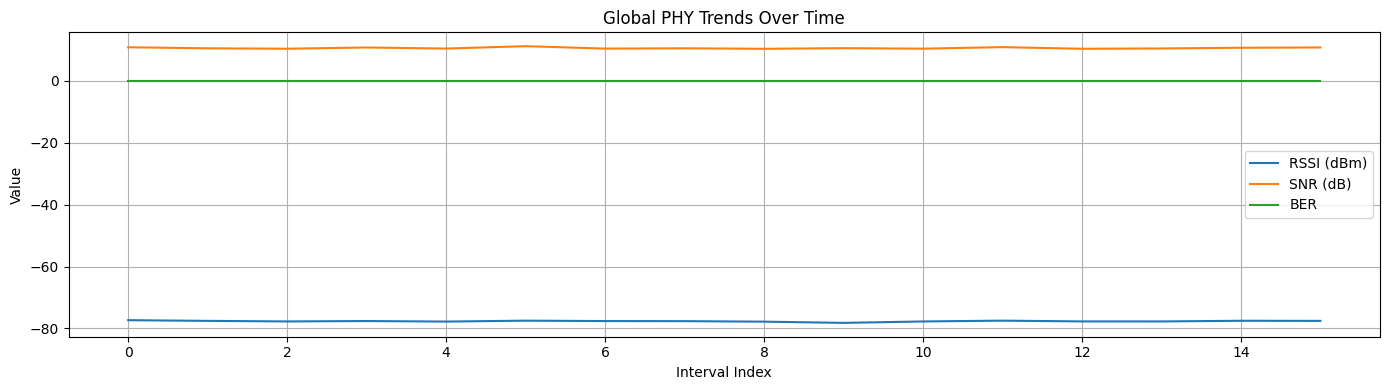

🔍 Plotting per-STA SNR heatmap...


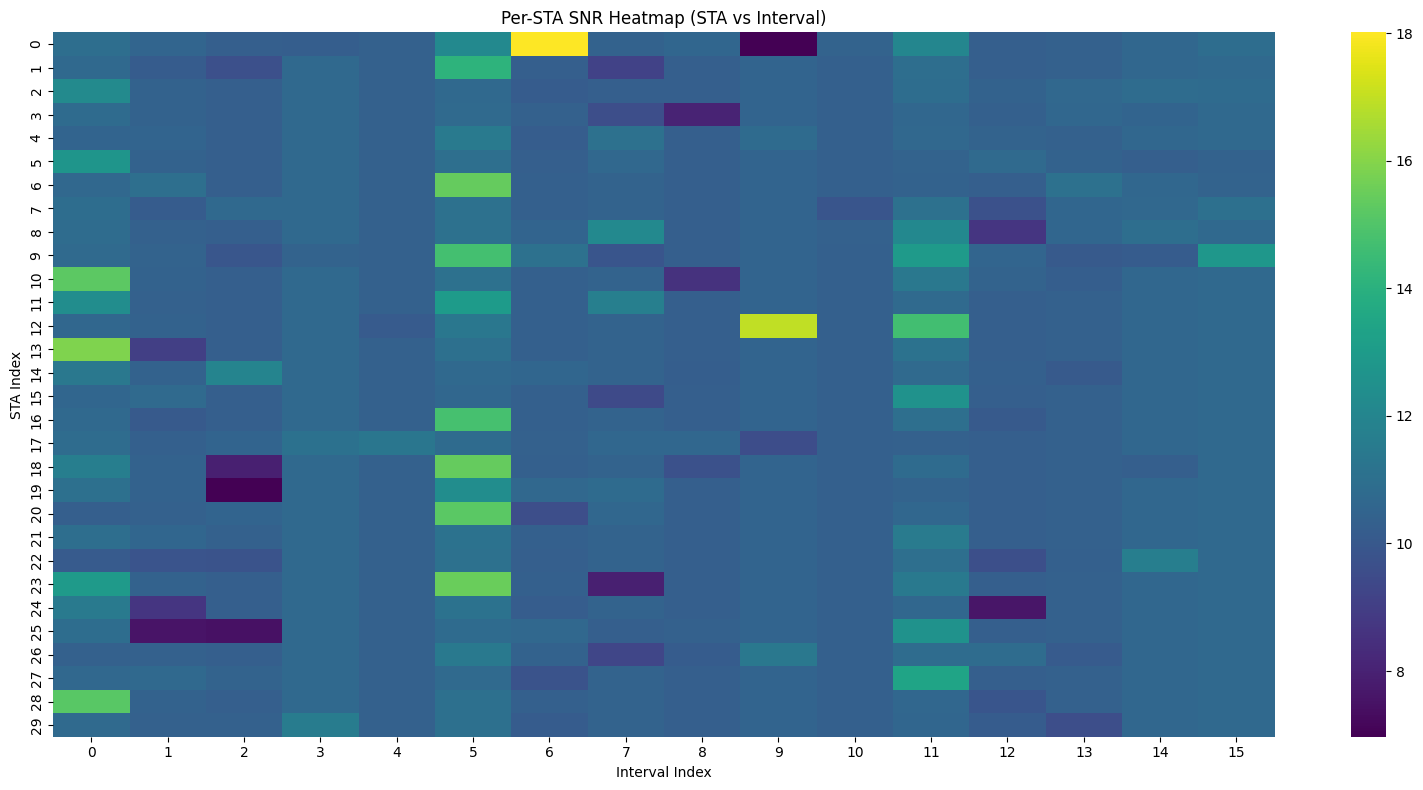

🔍 Plotting selected STA RSSI curves...


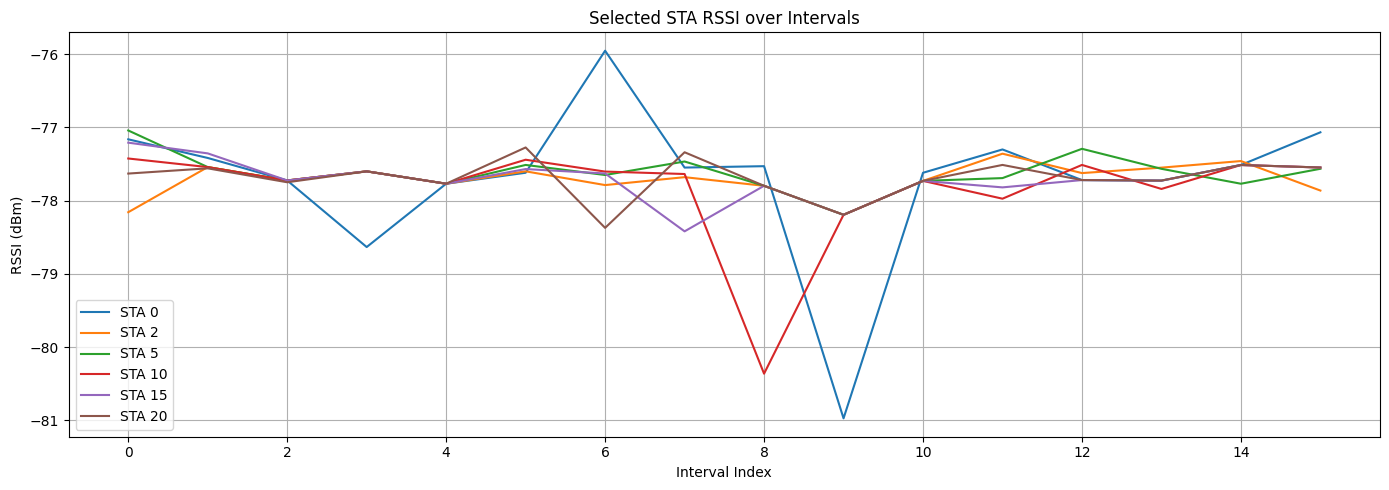

🔍 Plotting Node Density vs Throughput...


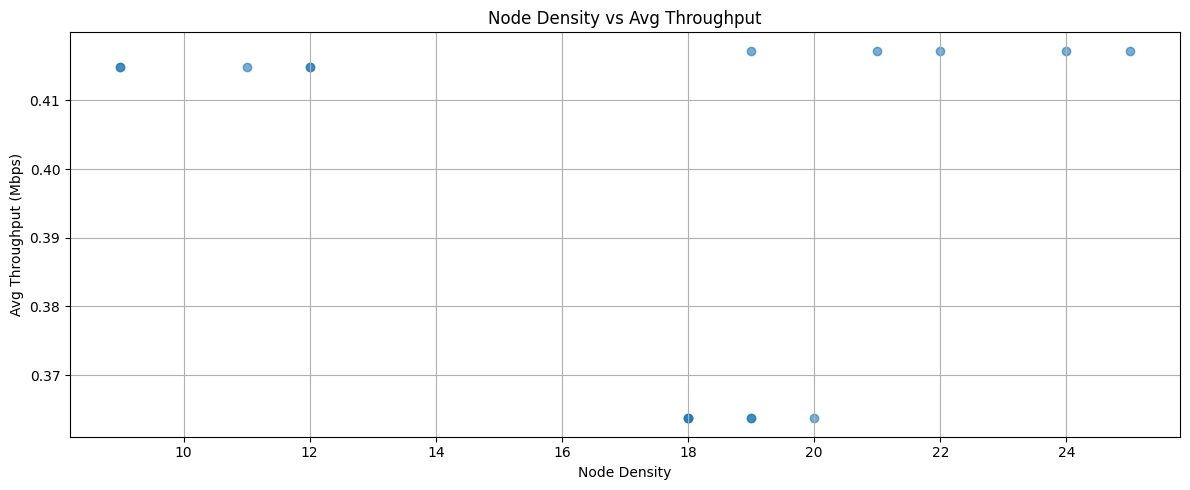

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# Load your merged dataset
# ----------------------------------------------------------
df = pd.read_csv("../outputs/combine_analysis/final_training_dataset.csv")

# Ensure datetime sorting
if "StartDateTime" in df.columns:
    df["StartDateTime"] = pd.to_datetime(df["StartDateTime"])
    df = df.sort_values("StartDateTime").reset_index(drop=True)


# ==========================================================
# 1) GLOBAL PHY TRENDS OVER TIME
# ==========================================================
def plot_global_phy(df):
    plt.figure(figsize=(14, 4))
    plt.plot(df["GlobalAvgRSSI(dBm)"], label="RSSI (dBm)")
    plt.plot(df["GlobalAvgSNR(dB)"],  label="SNR (dB)")
    plt.plot(df["GlobalAvgBER"],      label="BER")
    plt.title("Global PHY Trends Over Time")
    plt.xlabel("Interval Index")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================================================
# 2) PER-STA SNR HEATMAP
# ==========================================================
def plot_per_sta_snr_heatmap(df):
    # Identify per-STA SNR columns
    snr_cols = [c for c in df.columns if c.startswith("SNR_STA_")]
    snr_matrix = df[snr_cols].to_numpy().T  # STAs as rows

    plt.figure(figsize=(16, 8))
    sns.heatmap(snr_matrix, cmap="viridis", annot=False)
    plt.title("Per-STA SNR Heatmap (STA vs Interval)")
    plt.xlabel("Interval Index")
    plt.ylabel("STA Index")
    plt.tight_layout()
    plt.show()


# ==========================================================
# 3) RSSI Line Plot for a few selected STAs
# ==========================================================
def plot_selected_sta_rssi(df, sta_list=[0, 5, 10, 15]):
    plt.figure(figsize=(14, 5))
    for s in sta_list:
        col = f"RSSI_STA_{s}"
        if col in df.columns:
            plt.plot(df[col], label=f"STA {s}")

    plt.title("Selected STA RSSI over Intervals")
    plt.xlabel("Interval Index")
    plt.ylabel("RSSI (dBm)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================================================
# 4) Node Density vs Throughput
# ==========================================================
def plot_density_vs_throughput(df):
    plt.figure(figsize=(12, 5))
    plt.scatter(df["NodeDensity"], df["Perf_Avg_Throughput"], alpha=0.6)
    plt.title("Node Density vs Avg Throughput")
    plt.xlabel("Node Density")
    plt.ylabel("Avg Throughput (Mbps)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ==========================================================
# Execute all plots
# ==========================================================

print("🔍 Plotting Global PHY trends...")
plot_global_phy(df)

print("🔍 Plotting per-STA SNR heatmap...")
plot_per_sta_snr_heatmap(df)

print("🔍 Plotting selected STA RSSI curves...")
plot_selected_sta_rssi(df, sta_list=[0, 2, 5, 10, 15, 20])

print("🔍 Plotting Node Density vs Throughput...")
plot_density_vs_throughput(df)



📡 Plotting PHY ↔ Performance Correlation Map...


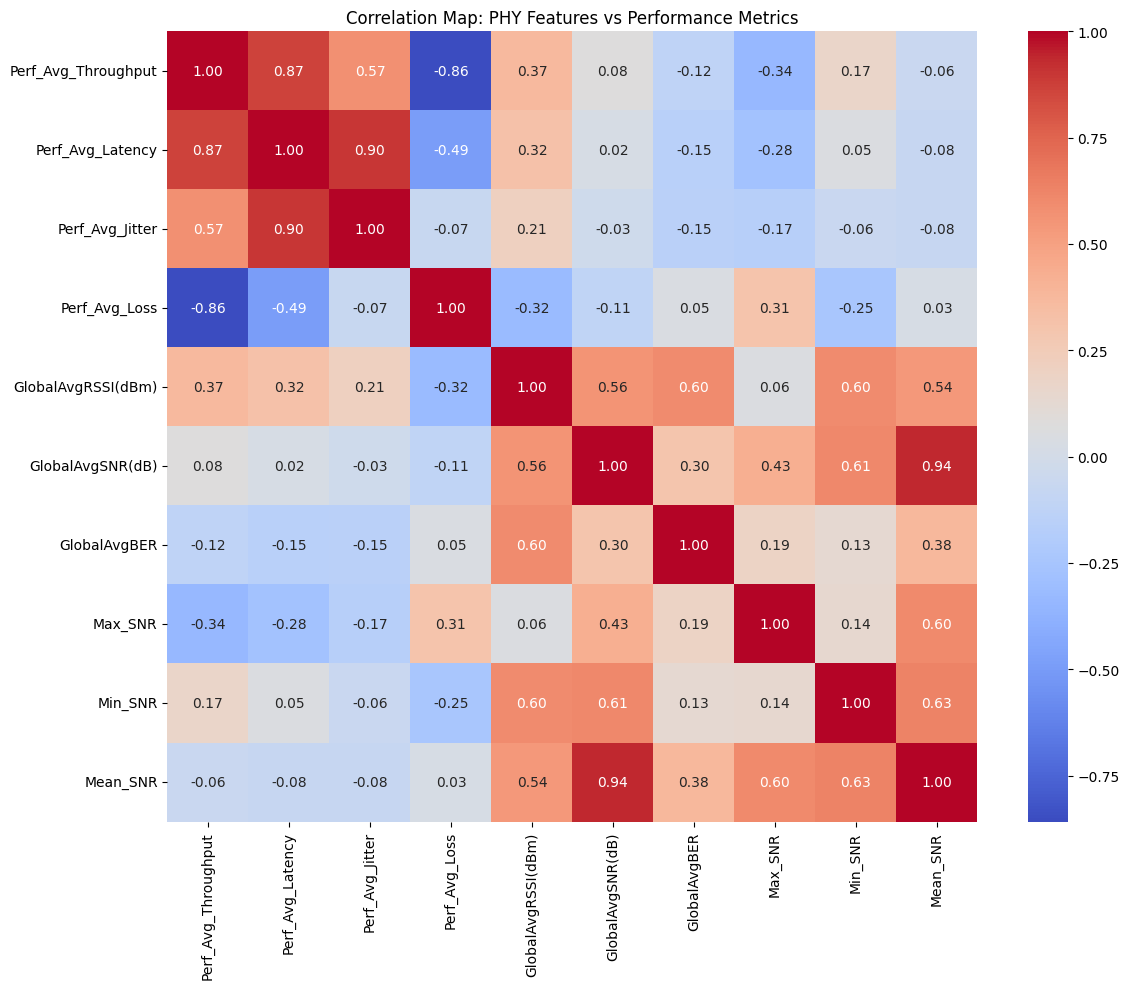


🎻 Plotting SNR Distribution (Violin)...


/tmp/ipykernel_35314/1350103200.py:53: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="STA", y="SNR", data=snr_data, scale="width", cut=0)


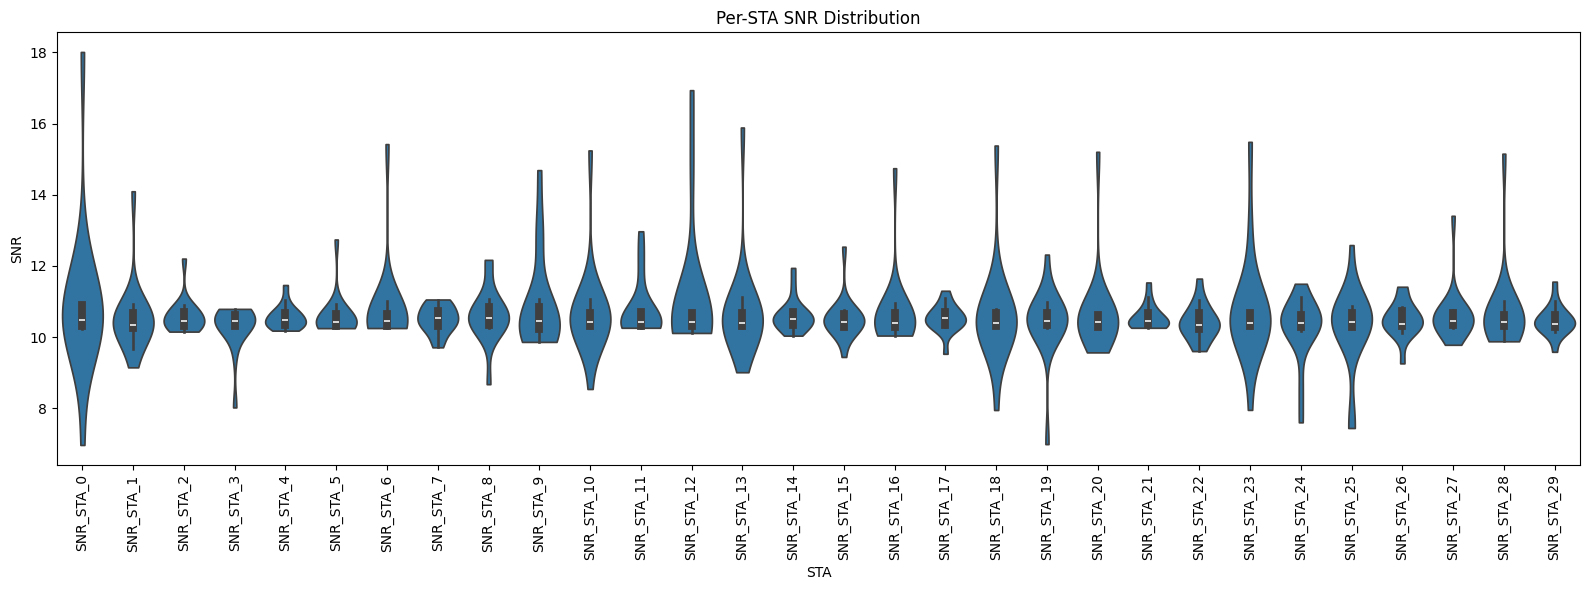


🌋 Plotting 3D SNR Surface...


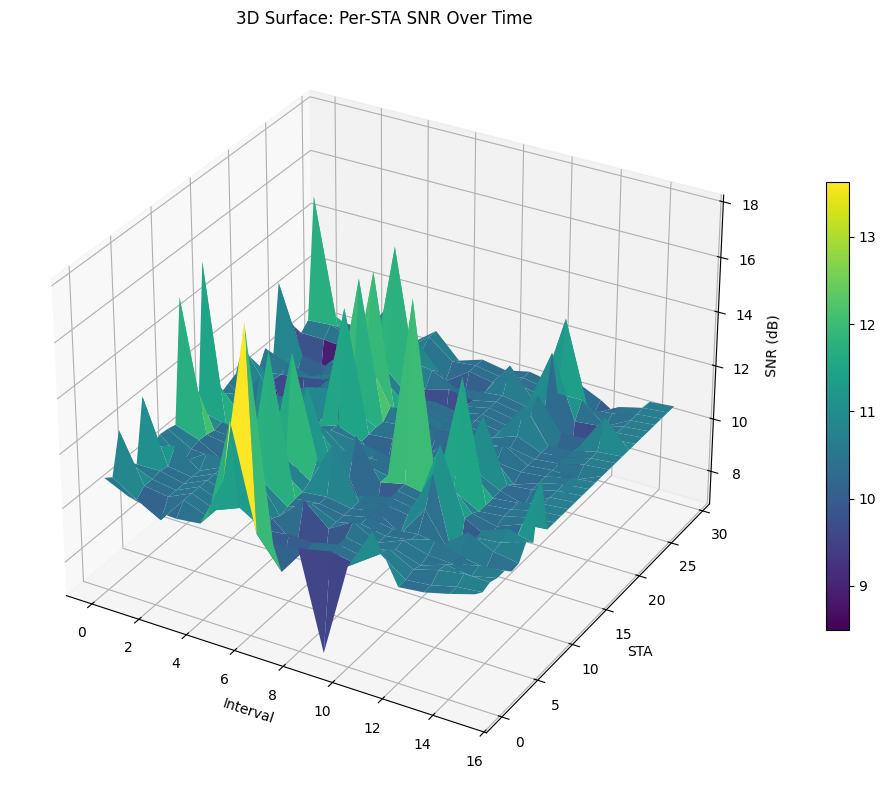


📉 Plotting Node Density vs Mean SNR Regression...


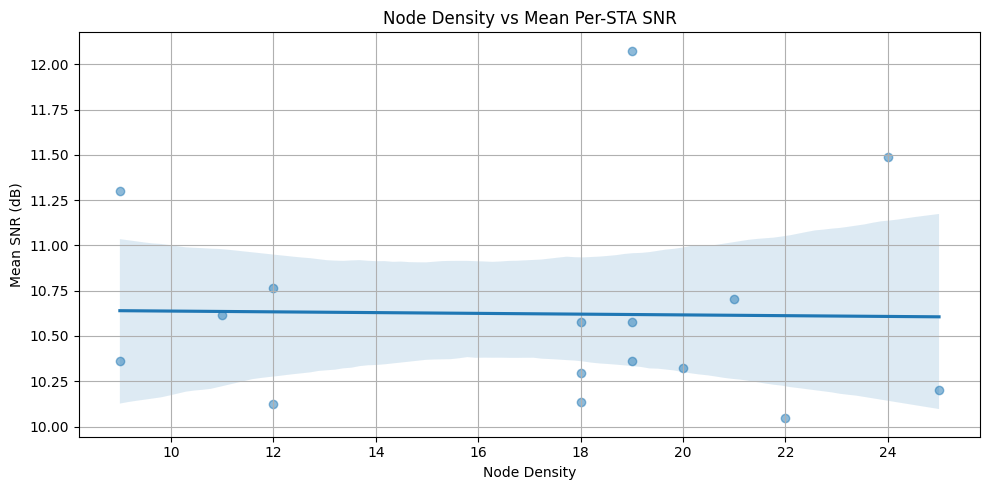


🚨 Plotting Worst STAs Over Intervals...


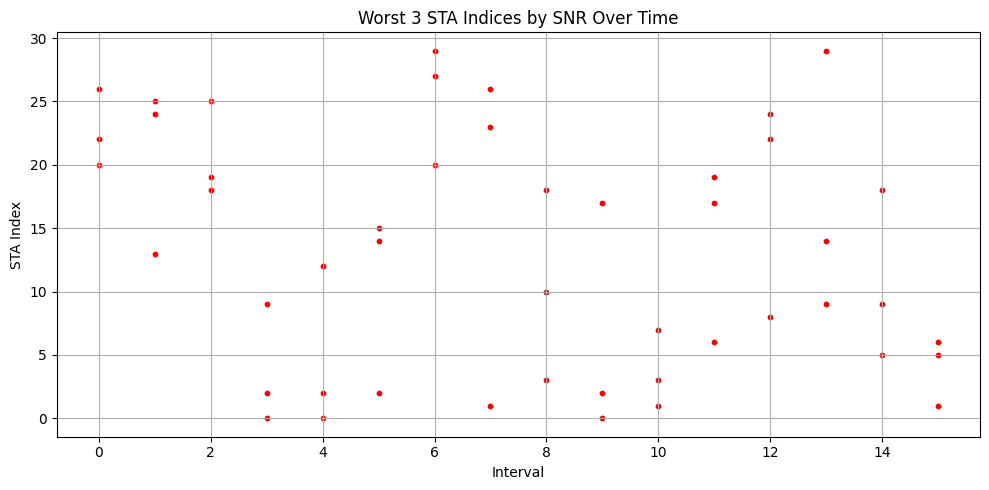


⚡ Plotting SNR Variability per STA...


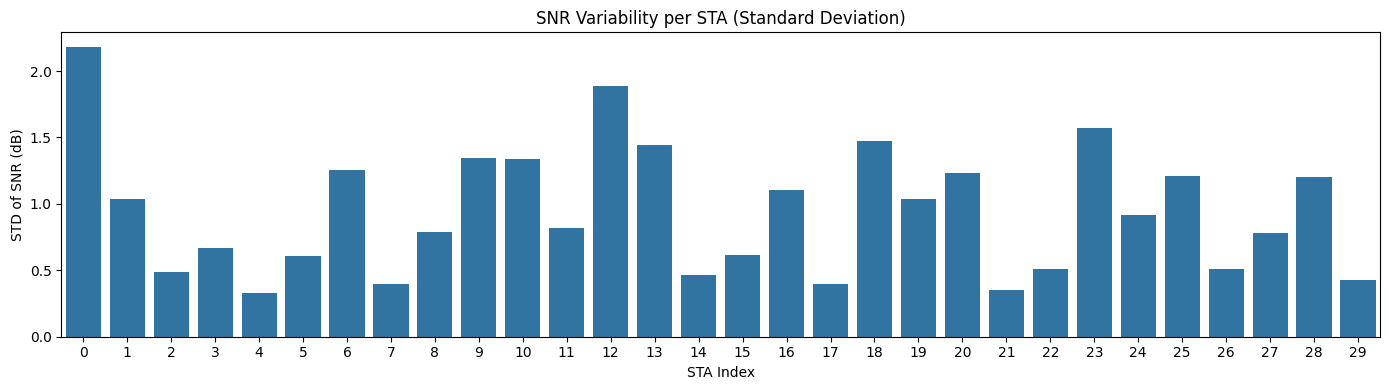

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
df = pd.read_csv("../outputs/combine_analysis/final_training_dataset.csv")

if "StartDateTime" in df.columns:
    df["StartDateTime"] = pd.to_datetime(df["StartDateTime"])
    df = df.sort_values("StartDateTime").reset_index(drop=True)


# ============================================================
# 1) CORRELATION HEATMAP (PHY → Performance)
# ============================================================

def plot_correlation_map(df):
    """Shows how RSSI, SNR, BER correlate with throughput, latency, jitter."""
    perf_cols = ["Perf_Avg_Throughput", "Perf_Avg_Latency", 
                 "Perf_Avg_Jitter", "Perf_Avg_Loss"]

    # pick some PHY columns
    phy_cols = ["GlobalAvgRSSI(dBm)", "GlobalAvgSNR(dB)", "GlobalAvgBER"]

    # also per-STA summary max/min
    df["Max_SNR"] = df[[c for c in df.columns if c.startswith("SNR_STA_")]].max(axis=1)
    df["Min_SNR"] = df[[c for c in df.columns if c.startswith("SNR_STA_")]].min(axis=1)
    df["Mean_SNR"] = df[[c for c in df.columns if c.startswith("SNR_STA_")]].mean(axis=1)

    corr_cols = perf_cols + phy_cols + ["Max_SNR", "Min_SNR", "Mean_SNR"]
    corr = df[corr_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Map: PHY Features vs Performance Metrics")
    plt.tight_layout()
    plt.show()



# ============================================================
# 2) PER-STA SNR DISTRIBUTION (violin)
# ============================================================

def plot_snr_distribution(df):
    snr_cols = [c for c in df.columns if c.startswith("SNR_STA_")]

    snr_data = df[snr_cols].melt(var_name="STA", value_name="SNR")

    plt.figure(figsize=(16, 6))
    sns.violinplot(x="STA", y="SNR", data=snr_data, scale="width", cut=0)
    plt.xticks(rotation=90)
    plt.title("Per-STA SNR Distribution")
    plt.tight_layout()
    plt.show()



# ============================================================
# 3) 3D SURFACE: Interval × STA × SNR
# ============================================================

def plot_snr_surface(df):
    snr_cols = [c for c in df.columns if c.startswith("SNR_STA_")]
    snr_matrix = df[snr_cols].to_numpy()

    X = np.arange(snr_matrix.shape[0])  # intervals
    Y = np.arange(snr_matrix.shape[1])  # STAs
    X, Y = np.meshgrid(X, Y)
    Z = snr_matrix.T

    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis")

    ax.set_title("3D Surface: Per-STA SNR Over Time")
    ax.set_xlabel("Interval")
    ax.set_ylabel("STA")
    ax.set_zlabel("SNR (dB)")
    fig.colorbar(surf, shrink=0.6)
    plt.tight_layout()
    plt.show()



# ============================================================
# 4) Node Density ↔ PHY Relationship (scatter + regression line)
# ============================================================

def plot_density_vs_snr(df):
    df["Mean_SNR"] = df[[c for c in df.columns if c.startswith("SNR_STA_")]].mean(axis=1)

    plt.figure(figsize=(10, 5))
    sns.regplot(x="NodeDensity", y="Mean_SNR", data=df, scatter_kws={"alpha":0.5})
    plt.title("Node Density vs Mean Per-STA SNR")
    plt.xlabel("Node Density")
    plt.ylabel("Mean SNR (dB)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# ============================================================
# 5) Top-k Worst STA Visualization (per interval)
# ============================================================

def plot_worst_sta_snr(df, k=3):
    snr_cols = [c for c in df.columns if c.startswith("SNR_STA_")]
    snr_matrix = df[snr_cols].to_numpy()

    worst_indices = np.argsort(snr_matrix, axis=1)[:, :k]  # top-k worst STAs

    plt.figure(figsize=(10, 5))
    for idx in range(len(df)):
        plt.scatter([idx]*k, worst_indices[idx], color="red", s=10)

    plt.title(f"Worst {k} STA Indices by SNR Over Time")
    plt.xlabel("Interval")
    plt.ylabel("STA Index")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# ============================================================
# 6) SNR Variability Heatmap (STA instability measure)
# ============================================================

def plot_snr_variability(df):
    snr_cols = [c for c in df.columns if c.startswith("SNR_STA_")]
    snr_std = df[snr_cols].std(axis=0).to_numpy()

    plt.figure(figsize=(14, 4))
    sns.barplot(x=list(range(len(snr_std))), y=snr_std)
    plt.title("SNR Variability per STA (Standard Deviation)")
    plt.xlabel("STA Index")
    plt.ylabel("STD of SNR (dB)")
    plt.tight_layout()
    plt.show()



# ============================================================
# Execute All Advanced Visualizations
# ============================================================

print("\n📡 Plotting PHY ↔ Performance Correlation Map...")
plot_correlation_map(df)

print("\n🎻 Plotting SNR Distribution (Violin)...")
plot_snr_distribution(df)

print("\n🌋 Plotting 3D SNR Surface...")
plot_snr_surface(df)

print("\n📉 Plotting Node Density vs Mean SNR Regression...")
plot_density_vs_snr(df)

print("\n🚨 Plotting Worst STAs Over Intervals...")
plot_worst_sta_snr(df, k=3)

print("\n⚡ Plotting SNR Variability per STA...")
plot_snr_variability(df)
